# Deep Dive: Physics, FEM Solver, and FNO Architecture

---

## 1. The Physical Governing Equation
The system simulates **non-linear heat conduction** in a 1D medium. We solve for the steady-state temperature distribution $T(x)$ where the material's ability to conduct heat is a function of both position and the temperature itself.

### The Non-Linear PDE:
$$\frac{d}{dx} \left[ k(x, T) \frac{dT}{dx} \right] = 0$$

### Thermal Conductivity Model ($k$):
$$k(x, T) = \phi(x) \cdot (1 + \beta T)$$

1.  **Spatial Profile $\phi(x)$**: This represents the "intrinsic" material property. It is generated using 12 randomized sine modes with a power-law decay ($1/f^{1.1}$) to ensure smooth, physically realistic spatial variations. In this implementation, it is normalized between **$K_{MIN}=0.1$** and **$K_{MAX}=1.0$**.
2.  **Temperature Dependence $(1 + \beta T)$**: The non-linearity factor $\beta$ (sampled between $0.1$ and $0.4$) dictates how much the conductivity increases as the material heats up.

---

## 2. The FEM Solver (Data Generation)
Because the PDE is non-linear, the code uses a **Finite Element Method (FEM)** framework coupled with a **Newton-Raphson** iterative solver to generate the ground truth.

### Discretization & Integration
*   **Elements**: The domain is divided into 64 linear elements (`n_grid`).
*   **Gaussian Quadrature**: The code uses a 2-point Gauss rule to integrate the stiffness matrix $K_{mat}$ and residual vector $R_{vec}$ within each element.

### Newton-Raphson Logic
The solver iteratively finds the temperature $T$ where the internal fluxes balance ($R \approx 0$):
1.  **Jacobian ($K_{mat}$)**: Calculates the sensitivity of the residual to temperature changes, including the $\beta$ non-linearity.
2.  **Correction**: Updates the temperature field via $\Delta T = -K_{mat}^{-1} \cdot R$.
3.  **Convergence**: The code performs a fixed **15-step scan** via `jax.lax.scan` to ensure high-fidelity convergence across all 500 samples.

---

## 3. FNO Architecture & Hard Constraints
The Fourier Neural Operator (FNO) learns the mapping from the conductivity profile $\phi(x)$ to the temperature field $T(x)$. Unlike standard neural networks, this model enforces the boundary conditions (BCs) **mathematically** rather than through the loss function.

### Hard Boundary Condition Enforcement
The model does not directly output the final temperature. Instead, it uses an **Ansatz** (structured output) to guarantee $T(0)=0$ and $T(1)=1$:
$$T_{pred} = \text{Interpolant} + (\text{Mask} \cdot \text{FNO}_{output})$$

*   **Interpolant ($x$)**: A linear function that satisfies the BCs ($0$ at $x=0$, $1$ at $x=1$).
*   **Mask ($x(1-x)$)**: A function that is exactly zero at both boundaries. This ensures that whatever the "raw" FNO predicts, the boundary values remain untouched.

---

### Technical Specifications

| Parameter | Value | Description |
| :--- | :--- | :--- |
| `train_samples` | 200 | Number of training samples used for weight updates. |
| `modes` | 4 | Lower frequency modes preserved in Fourier space. |
| `width` | 64 | Channel depth of the hidden spectral layers. |
| `Layers` | 4 Fourier / 4 Dense | Total depth of the operator architecture. |
| `Hard BCs` | Enabled | Guaranteed $T(0)=0, T(1)=1$ via physical masking. |
| `AdamW` | $10^{-3}$ | Learning rate with weight decay ($10^{-4}$) for stability. |

---

## 4. Why This Approach?
By using **Hard BCs**, the model doesn't have to "learn" that the ends of the rod are fixed—it is physically impossible for the model to predict anything else. This significantly speeds up training and ensures the error is concentrated in the interior of the domain where the complex non-linear physics occurs, rather than "bleeding" at the boundaries.

Generating Synthetic FEM Data...
Training FNO with Hard BC Constraints...
Step     0 | MSE Loss: 1.58671606e-02
Step  1000 | MSE Loss: 1.47379586e-03
Step  2000 | MSE Loss: 2.03395658e-03
Step  3000 | MSE Loss: 2.70444521e-04
Step  4000 | MSE Loss: 1.16961112e-03
Step  5000 | MSE Loss: 4.51083470e-04
Step  6000 | MSE Loss: 2.73845653e-04
Step  7000 | MSE Loss: 4.16705298e-04
Step  8000 | MSE Loss: 2.24248201e-04
Step  9000 | MSE Loss: 1.91375861e-04
Step 10000 | MSE Loss: 1.87573052e-04


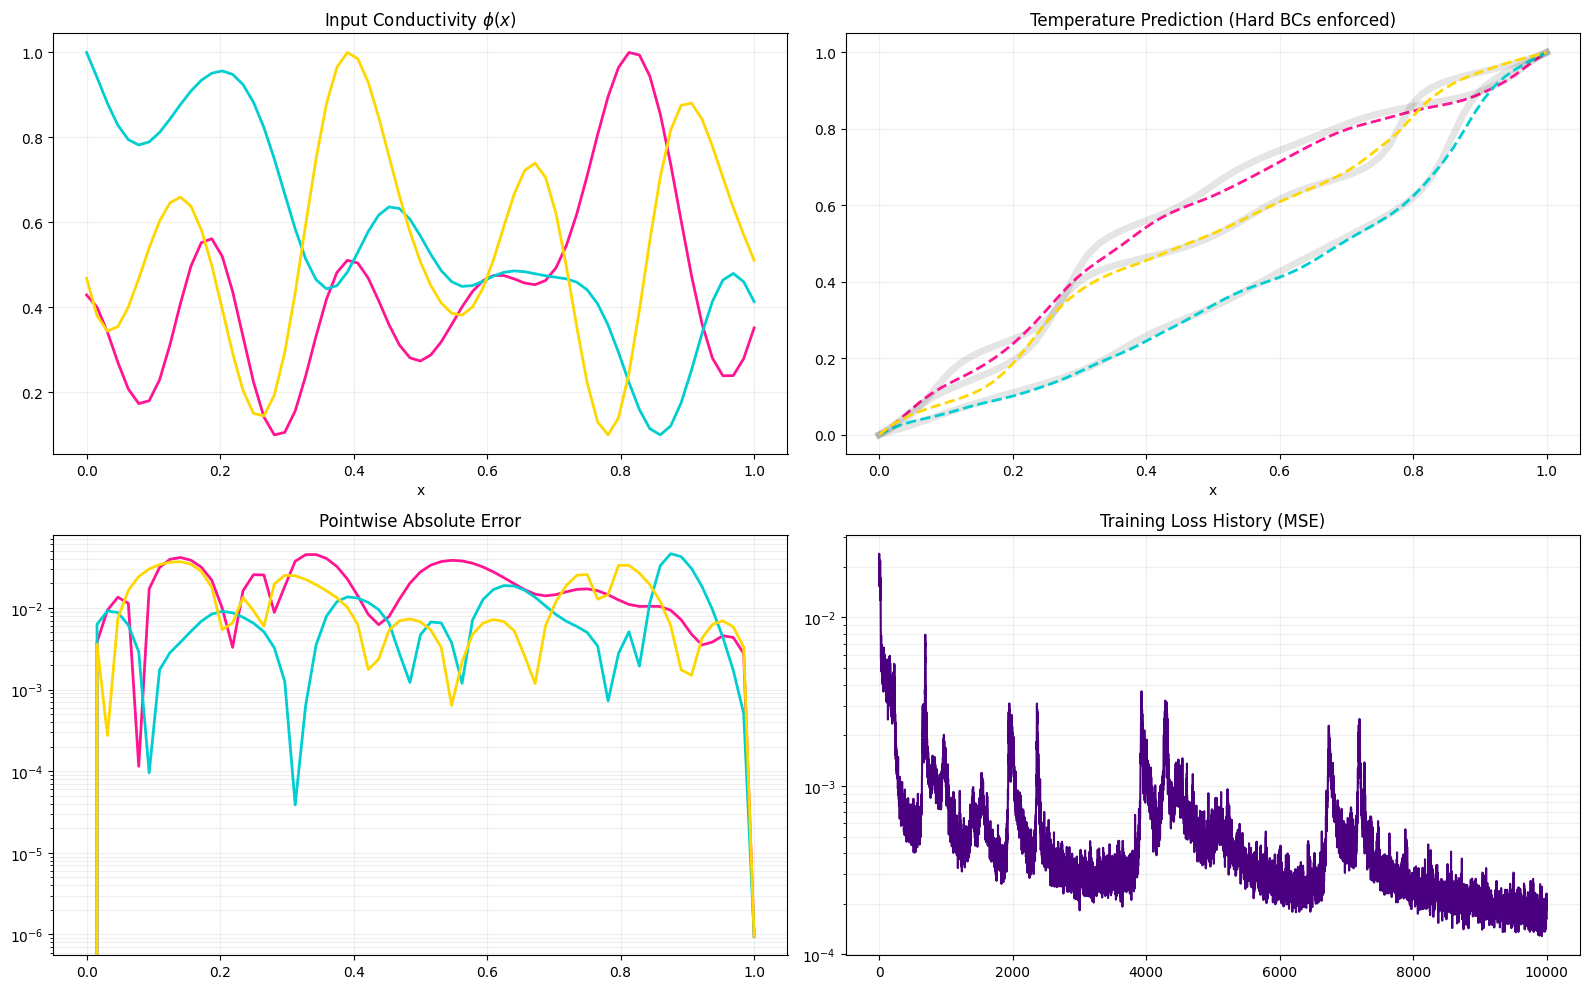

In [ ]:
# @title
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

# --- 1. GLOBAL SETTINGS ---
n_grid = 64
n_nodes = n_grid + 1
width = 64
modes = 4
batch_size = 32
epochs = 10001
n_samples = 500
train_samples = 200
K_MIN, K_MAX = 0.1, 1.0

# --- 2. GENERATOR (FEM Solver) ---
@jax.jit
def solve_fem_sample(key, beta):
    dx = 1.0 / n_grid
    x_nodes = jnp.linspace(0, 1, n_nodes)
    k1, k2, k3 = jax.random.split(key, 3)

    freqs = jnp.arange(1, 13)
    amps = jax.random.normal(k2, (12,)) / (freqs**1.1)
    phases = jax.random.uniform(k3, (12,), minval=0, maxval=2*jnp.pi)
    raw_phi = jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x_nodes + phases[:, None]), axis=0)

    phi_norm = (raw_phi - raw_phi.min()) / (raw_phi.max() - raw_phi.min() + 1e-8)
    phi_profile = K_MIN + (K_MAX - K_MIN) * phi_norm

    def nr_step(T, _):
        K_mat, R_vec = jnp.zeros((n_nodes, n_nodes)), jnp.zeros(n_nodes)
        for e in range(n_grid):
            ix = jnp.array([e, e + 1])
            xi, wi = 0.57735, 1.0
            for s in [-1, 1]:
                N, B = jnp.array([0.5*(1-s*xi), 0.5*(1+s*xi)]), jnp.array([-0.5, 0.5])/(dx/2.0)
                p_gp, T_gp = jnp.dot(N, phi_profile[ix]), jnp.dot(N, T[ix])
                k = p_gp * (1.0 + beta * T_gp)
                dk = p_gp * beta
                R_vec = R_vec.at[ix].add((B * k * jnp.dot(B, T[ix])) * (dx/2.0) * wi)
                K_mat = K_mat.at[jnp.ix_(ix, ix)].add((jnp.outer(B, B)*k + jnp.outer(B, N)*dk*jnp.dot(B, T[ix]))*(dx/2.0)*wi)
        free = jnp.arange(1, n_nodes - 1)
        dT = jnp.linalg.solve(K_mat[jnp.ix_(free, free)], -R_vec[free])
        return T.at[free].add(dT), None

    final_T, _ = jax.lax.scan(nr_step, jnp.linspace(0, 1, n_nodes), None, length=15)
    return phi_profile, final_T

# --- 3. DATA PREPARATION ---
print("Generating Synthetic FEM Data...")
betas = jax.random.uniform(jax.random.PRNGKey(7), shape=(n_samples,), minval=0.1, maxval=0.4)
all_K, all_T = jax.vmap(solve_fem_sample)(jax.random.split(jax.random.PRNGKey(42), n_samples), betas)
all_Y = ((all_T - all_T.min()) / (all_T.max() - all_T.min() + 1e-6))[:, :, None]

grid = jnp.linspace(0, 1, n_nodes)
grid_tiled = jnp.tile(grid, (n_samples, 1))
all_X_raw = jnp.stack([all_K, grid_tiled], axis=-1)
x_mean, x_std = all_X_raw[:train_samples].mean(axis=(0,1)), all_X_raw[:train_samples].std(axis=(0,1)) + 1e-7
all_X = (all_X_raw - x_mean) / x_std

# --- 4. FNO MODEL WITH ENFORCED BCs ---
def spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:modes].set(jnp.einsum('mi, mij -> mj', x_ft[:modes], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(params, x_in, grid_phys):
    """
    x_in: Normalized input features (K, grid)
    grid_phys: Physical grid [0, 1] used for BC masking
    """
    # Lifting
    x = jax.nn.gelu(jnp.dot(x_in, params[0]) + params[1])
    x = jax.nn.gelu(jnp.dot(x, params[2]) + params[3])

    # 4 Fourier Layers
    for i in range(4, 12, 2):
        x = spectral_layer(x, params[i], params[i+1])

    # Projection
    x = jax.nn.gelu(jnp.dot(x, params[12]) + params[13])
    raw_out = jnp.dot(x, params[14]) + params[15] # (nodes, 1)

    # --- ENFORCE BCs: T(0)=0, T(1)=1 ---
    # Interpolant satisfies boundaries: (1-x)*0 + x*1 = x
    interpolant = grid_phys[:, None]
    # Mask is zero at x=0 and x=1
    mask = (grid_phys * (1.0 - grid_phys))[:, None]

    return interpolant + mask * raw_out

# --- 5. INITIALIZATION ---
def init_params(key):
    keys = jax.random.split(key, 13)
    scale_spec = jnp.sqrt(1.0 / (width * width))
    scale_lin = jnp.sqrt(1.0 / width)

    params = [
        # Lifting
        jax.random.normal(keys[0], (2, width)) * scale_lin, jnp.zeros(width),
        jax.random.normal(keys[1], (width, width)) * scale_lin, jnp.zeros(width),
    ]
    # 4 Fourier Layers
    for i in range(4):
        params.append(jax.random.normal(keys[i+2], (modes, width, width), dtype=jnp.complex64) * scale_spec)
        params.append(jax.random.normal(keys[i+6], (width, width)) * scale_lin)

    # Projection
    params.extend([
        jax.random.normal(keys[10], (width, width)) * scale_lin, jnp.zeros(width),
        jax.random.normal(keys[11], (width, 1)) * scale_lin, jnp.zeros(1)
    ])
    return params

params = init_params(jax.random.PRNGKey(0))
optimizer = optax.adamw(optax.exponential_decay(1e-3, 5000, 0.5), weight_decay=1e-4)
opt_state = optimizer.init(params)

@jax.jit
def train_step(p, opt_s, xb, yb, g_phys):
    # g_phys is the physical grid passed to enforce BCs
    loss_fn = lambda p: jnp.mean((jax.vmap(fno_model, (None, 0, None))(p, xb, g_phys) - yb)**2)
    l, g = jax.value_and_grad(loss_fn)(p)
    u, opt_s = optimizer.update(g, opt_s, p)
    return optax.apply_updates(p, u), opt_s, l

# --- 6. TRAINING LOOP ---
loss_history = []
print("Training FNO with Hard BC Constraints...")
for i in range(epochs):
    idx = jax.random.randint(jax.random.PRNGKey(i), (batch_size,), 0, train_samples)
    params, opt_state, loss = train_step(params, opt_state, all_X[idx], all_Y[idx], grid)
    loss_history.append(float(loss))
    if i % 1000 == 0:
        print(f"Step {i:5d} | MSE Loss: {loss:.8e}")

# --- 7. FINAL VISUALIZATION ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
test_idxs = [250, 350, 450]
colors = ['#FF1493', '#00CED1', '#FFD700']

# Plot 1: Input Conductivity
for idx, c in zip(test_idxs, colors):
    ax1.plot(grid, all_K[idx], color=c, lw=2, label=f"K {idx}")
ax1.set_title(r"Input Conductivity $\phi(x)$")
ax1.set_xlabel("x")
ax1.grid(True, alpha=0.2)

# Plot 2: Temperature Predictions
for idx, c in zip(test_idxs, colors):
    pred = fno_model(params, all_X[idx], grid)
    ax2.plot(grid, all_Y[idx], color='black', lw=5, alpha=0.1)
    ax2.plot(grid, pred, color=c, ls='--', lw=2, label=f"FNO {idx}")
ax2.set_title("Temperature Prediction (Hard BCs enforced)")
ax2.set_xlabel("x")
ax2.grid(True, alpha=0.2)

# Plot 3: Pointwise Error
for idx, c in zip(test_idxs, colors):
    pred = fno_model(params, all_X[idx], grid)
    error = jnp.abs(all_Y[idx].flatten() - pred.flatten())
    ax3.plot(grid, error, color=c, lw=2)
ax3.set_title("Pointwise Absolute Error")
ax3.set_yscale('log')
ax3.grid(True, which="both", ls="-", alpha=0.2)

# Plot 4: Loss History
ax4.plot(loss_history, color='#4B0082', lw=1.5)
ax4.set_title("Training Loss History (MSE)")
ax4.set_yscale('log')
ax4.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

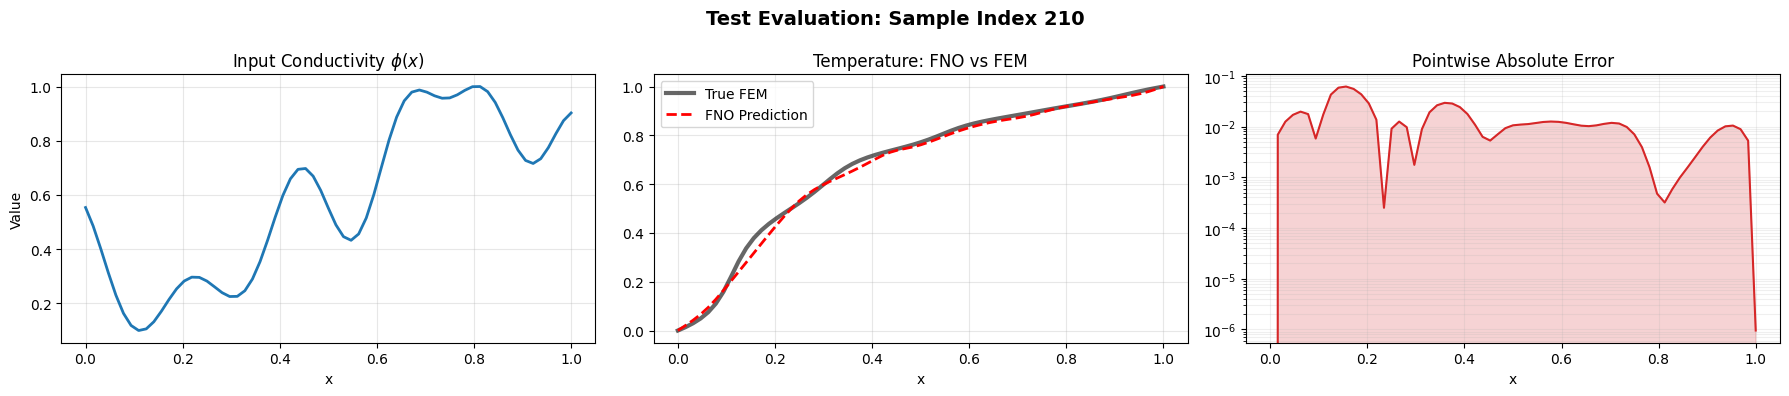

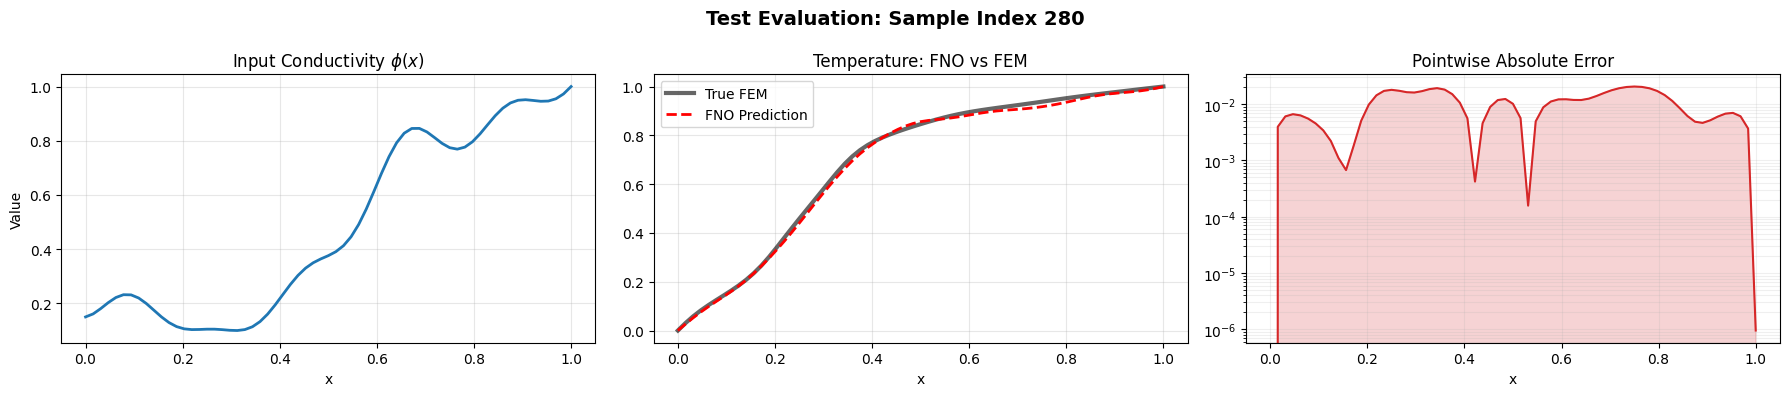

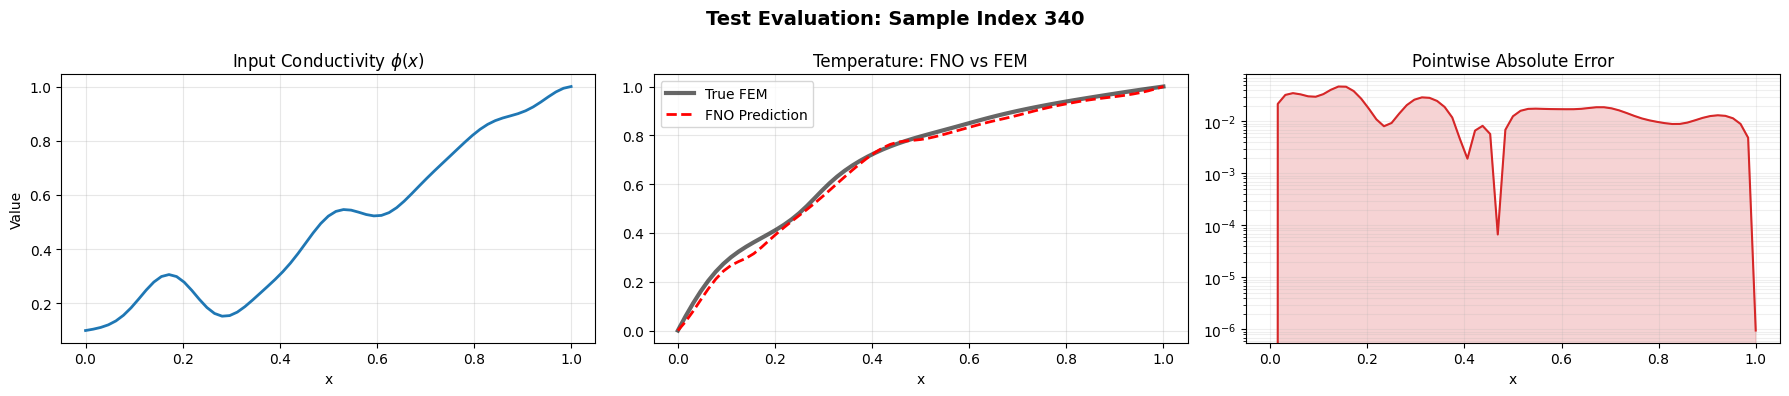

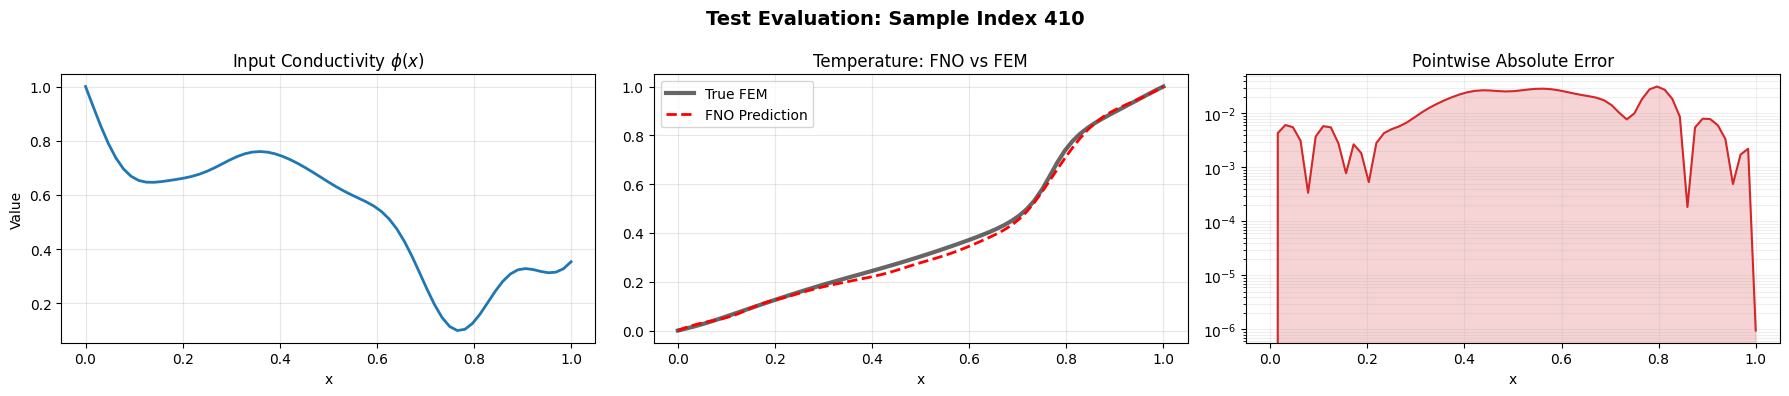

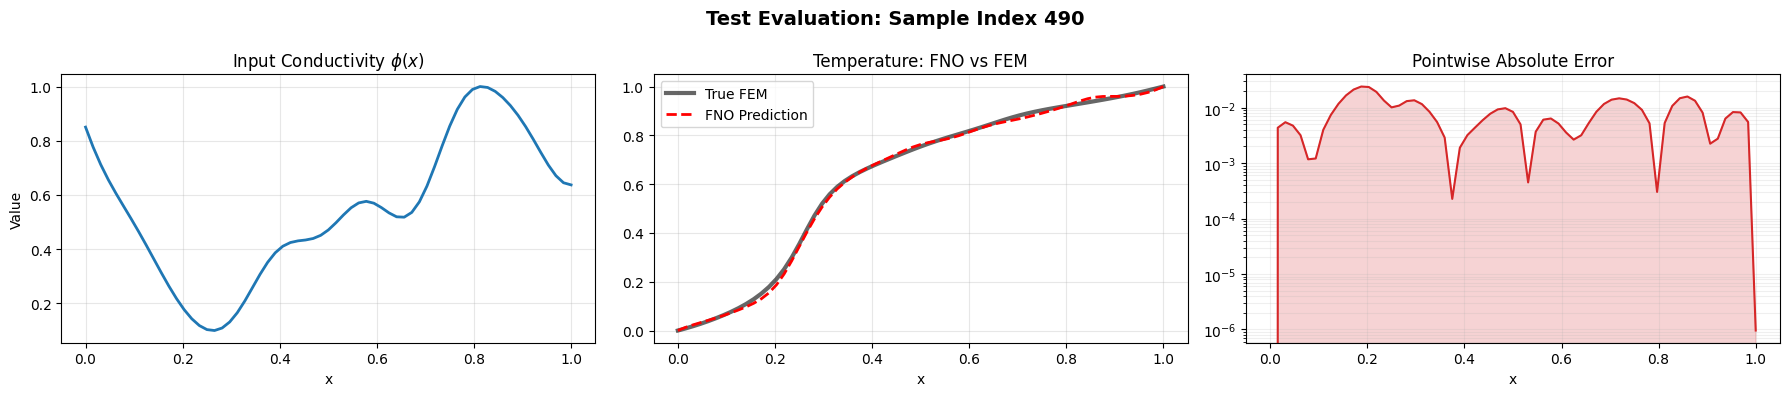

In [ ]:
# @title
# --- 8. INDIVIDUAL TEST EVALUATIONS (5 SAMPLES) ---
test_sample_indices = [210, 280, 340, 410, 490] # Indices from the test set

for idx in test_sample_indices:
    # 1. Get prediction
    # We use all_X[idx] which was not used in the training loop (0-200)
    pred = fno_model(params, all_X[idx], grid)
    true = all_Y[idx]
    k_input = all_K[idx]

    # 2. Calculate Error
    error = jnp.abs(true.flatten() - pred.flatten())

    # 3. Create Plots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Test Evaluation: Sample Index {idx}", fontsize=14, fontweight='bold')

    # Plot 1: Input Conductivity (K)
    ax1.plot(grid, k_input, color='tab:blue', lw=2)
    ax1.set_title(r"Input Conductivity $\phi(x)$")
    ax1.set_xlabel("x")
    ax1.set_ylabel("Value")
    ax1.grid(True, alpha=0.3)

    # Plot 2: FNO vs FEM (Temperature)
    ax2.plot(grid, true, 'k-', lw=3, label='True FEM', alpha=0.6)
    ax2.plot(grid, pred, 'r--', lw=2, label='FNO Prediction')
    ax2.set_title("Temperature: FNO vs FEM")
    ax2.set_xlabel("x")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Pointwise Error
    ax3.fill_between(grid, error, color='tab:red', alpha=0.2)
    ax3.plot(grid, error, color='tab:red', lw=1.5)
    ax3.set_title("Pointwise Absolute Error")
    ax3.set_xlabel("x")
    ax3.set_yscale('log')
    ax3.grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.show()

Running generalization tests with Hard BC enforcement...


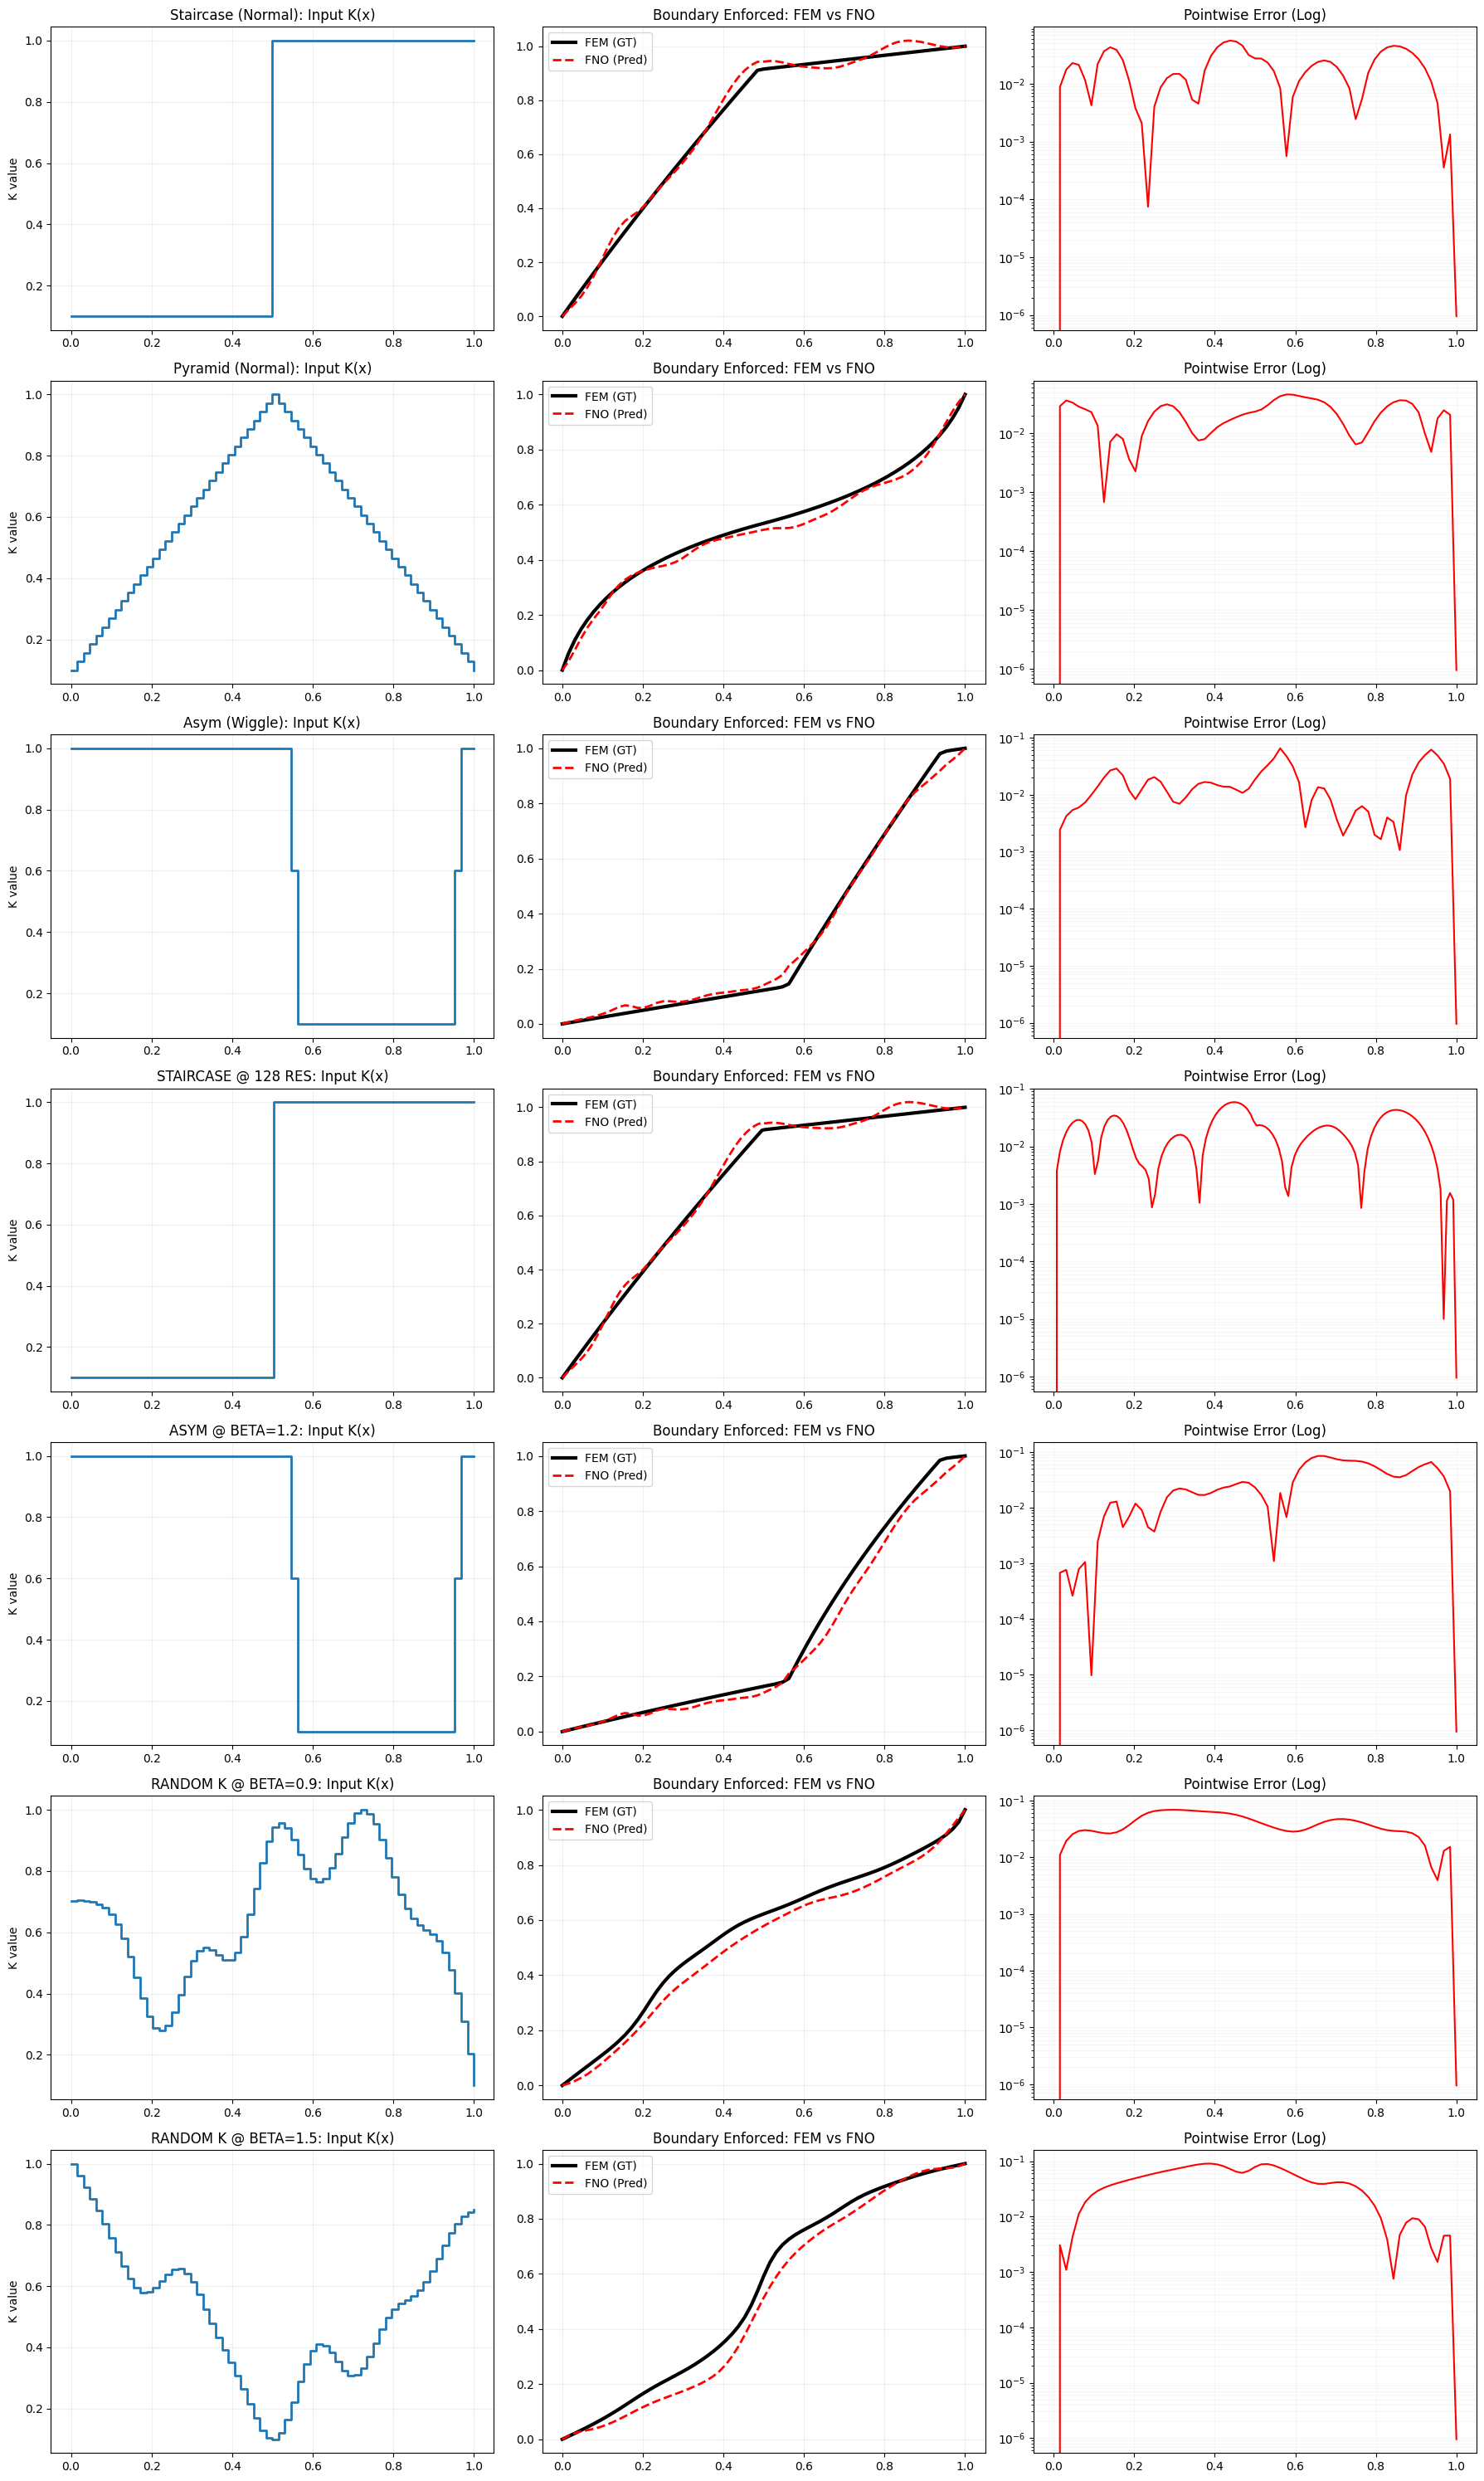

In [ ]:
# @title
# --- 1. CONFIGURATION & CONSTANTS ---
n_nodes_high = 128
BETA_EXTREME_2 = 1.2

# We must use the exact same stats used during training for normalization
# These variables (all_T, x_mean, x_std) must exist in your workspace from the previous script
T_MIN_GLOBAL = all_T.min()
T_MAX_GLOBAL = all_T.max()

# --- 2. GEOMETRY & PROFILE HELPERS ---
def get_staircase(n):
    return jnp.where(jnp.linspace(0, 1, n) < 0.5, K_MIN, K_MAX)

def get_pyramid(n):
    x = jnp.linspace(0, 1, n)
    return K_MIN + (K_MAX - K_MIN) * (1.0 - jnp.abs(2 * x - 1))

def get_asym(n):
    x = jnp.linspace(0, 1, n)
    val = K_MIN + 4 * jnp.sin(2 * jnp.pi * x) + 2 * jnp.cos(4 * jnp.pi * x)
    return jnp.clip(val, K_MIN, K_MAX)

def get_random_k(key, n):
    freqs = jnp.arange(1, 13)
    k1, k2, k3 = jax.random.split(key, 3)
    amps = jax.random.normal(k2, (12,)) / (freqs**1.1)
    phases = jax.random.uniform(k3, (12,), minval=0, maxval=2*jnp.pi)
    x_nodes = jnp.linspace(0, 1, n)
    raw_phi = jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi * x_nodes + phases[:, None]), axis=0)
    phi_norm = (raw_phi - raw_phi.min()) / (raw_phi.max() - raw_phi.min() + 1e-8)
    return K_MIN + (K_MAX - K_MIN) * phi_norm

# --- 3. STANDALONE FEM SOLVER ---
@jax.jit
def fem_solver(phi_profile, beta):
    n = phi_profile.shape[0]
    dx = 1.0 / (n - 1)

    def nr_step(T, _):
        K_mat, R_vec = jnp.zeros((n, n)), jnp.zeros(n)
        for e in range(n - 1):
            ix = jnp.array([e, e + 1])
            xi, wi = 0.57735, 1.0
            for s in [-1, 1]:
                N = jnp.array([0.5*(1-s*xi), 0.5*(1+s*xi)])
                B = jnp.array([-0.5, 0.5])/(dx/2.0)
                p_gp, T_gp = jnp.dot(N, phi_profile[ix]), jnp.dot(N, T[ix])
                k = p_gp * (1.0 + beta * T_gp)
                dk = p_gp * beta
                R_vec = R_vec.at[ix].add((B * k * jnp.dot(B, T[ix])) * (dx/2.0) * wi)
                K_mat = K_mat.at[jnp.ix_(ix, ix)].add((jnp.outer(B, B)*k + jnp.outer(B, N)*dk*jnp.dot(B, T[ix]))*(dx/2.0)*wi)

        free = jnp.arange(1, n - 1)
        dT = jnp.linalg.solve(K_mat[jnp.ix_(free, free)], -R_vec[free])
        return T.at[free].add(dT), None

    # Initial guess 0 to 1 satisfies BCs for the solver
    final_T, _ = jax.lax.scan(nr_step, jnp.linspace(0, 1, n), None, length=15)

    # Normalize to [0, 1] using the GLOBAL training bounds
    # This ensures the FEM '1.0' matches the FNO '1.0'
    return (final_T - T_MIN_GLOBAL) / (T_MAX_GLOBAL - T_MIN_GLOBAL + 1e-6)

# --- 4. TEST WRAPPER ---
def run_test(k_profile, beta, n):
    """Bridges FEM ground truth with BC-Enforced FNO inference."""
    # 1. Ground Truth
    y_fem = fem_solver(k_profile, beta)

    # 2. Prepare FNO Input [K(x), x]
    grid_local = jnp.linspace(0, 1, n)
    x_raw = jnp.stack([k_profile, grid_local], axis=-1)

    # 3. Z-Score Normalization (using training stats from previous block)
    x_norm = (x_raw - x_mean) / x_std

    # 4. FNO Prediction - PASSING THE LOCAL GRID FOR BC ENFORCEMENT
    # fno_model(params, x_in, grid_phys)
    y_pred = fno_model(params, x_norm, grid_local).flatten()

    return k_profile, y_fem, y_pred

# --- 5. EXECUTION ---
print("Running generalization tests with Hard BC enforcement...")
results = [
    run_test(get_staircase(n_nodes), 0.25, n_nodes),           # 1. Staircase
    run_test(get_pyramid(n_nodes), 0.3, n_nodes),             # 2. Pyramid
    run_test(get_asym(n_nodes), 0.2, n_nodes),                # 3. Asymmetric
    run_test(get_staircase(n_nodes_high), 0.25, n_nodes_high),# 4. High Res (128) - FNO is resolution invariant!
    run_test(get_asym(n_nodes), BETA_EXTREME_2, n_nodes),     # 5. High Non-linear
    run_test(get_random_k(jax.random.PRNGKey(101), n_nodes), 0.9, n_nodes), # 6. High Beta
    run_test(get_random_k(jax.random.PRNGKey(202), n_nodes), 1.5, n_nodes)  # 7. Ultra High Beta
]

titles = ["Staircase (Normal)", "Pyramid (Normal)", "Asym (Wiggle)",
          "STAIRCASE @ 128 RES", f"ASYM @ BETA={BETA_EXTREME_2}",
          "RANDOM K @ BETA=0.9", "RANDOM K @ BETA=1.5"]

# --- 6. PLOTTING ---
fig, axes = plt.subplots(7, 3, figsize=(18, 30))

for i, (k_p, y_f, y_p) in enumerate(results):
    grid_local = jnp.linspace(0, 1, len(k_p))

    # Column 0: Conductivity Profile
    axes[i, 0].step(grid_local, k_p, where='post', color='#1f77b4', lw=2)
    axes[i, 0].set_title(f"{titles[i]}: Input K(x)")
    axes[i, 0].set_ylabel("K value")
    axes[i, 0].grid(True, alpha=0.2)

    # Column 1: Temperature Prediction
    axes[i, 1].plot(grid_local, y_f, 'k-', lw=3, label='FEM (GT)')
    axes[i, 1].plot(grid_local, y_p, 'r--', lw=2, label='FNO (Pred)')
    axes[i, 1].legend()
    axes[i, 1].set_title("Boundary Enforced: FEM vs FNO")
    axes[i, 1].grid(True, alpha=0.2)

    # Column 2: Absolute Error
    err = jnp.abs(y_f - y_p)
    axes[i, 2].plot(grid_local, err, color='red')
    axes[i, 2].set_yscale('log')
    axes[i, 2].set_title("Pointwise Error (Log)")
    axes[i, 2].grid(True, which="both", ls="-", alpha=0.1)

plt.tight_layout()
plt.show()